In [80]:
import pandas as pd

# Path to the CSV file in the ESC-50 dataset
Path = '/Users/bchhaglani/Desktop/Audio_privacy/ESC-50-master/'
csv_path = Path + 'meta/esc50.csv'

# Load the CSV into a DataFrame
df = pd.read_csv(csv_path)
audio_path_prefix = Path+'/audio/'


df = df[['filename', 'category']]

print(df.head())


            filename        category
0   1-100032-A-0.wav             dog
1  1-100038-A-14.wav  chirping_birds
2  1-100210-A-36.wav  vacuum_cleaner
3  1-100210-B-36.wav  vacuum_cleaner
4  1-101296-A-19.wav    thunderstorm


In [81]:
import numpy as np
import pandas as pd
import librosa
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [82]:
df = pd.read_csv(csv_path)
df['category'].unique()
# df['target'].unique()
# df[['target', 'category']]

array(['dog', 'chirping_birds', 'vacuum_cleaner', 'thunderstorm',
       'door_wood_knock', 'can_opening', 'crow', 'clapping', 'fireworks',
       'chainsaw', 'airplane', 'mouse_click', 'pouring_water', 'train',
       'sheep', 'water_drops', 'church_bells', 'clock_alarm',
       'keyboard_typing', 'wind', 'footsteps', 'frog', 'cow',
       'brushing_teeth', 'car_horn', 'crackling_fire', 'helicopter',
       'drinking_sipping', 'rain', 'insects', 'laughing', 'hen', 'engine',
       'breathing', 'crying_baby', 'hand_saw', 'coughing',
       'glass_breaking', 'snoring', 'toilet_flush', 'pig',
       'washing_machine', 'clock_tick', 'sneezing', 'rooster',
       'sea_waves', 'siren', 'cat', 'door_wood_creaks', 'crickets'],
      dtype=object)

In [83]:
import numpy as np
import pandas as pd
import librosa
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load the dataset metadata
csv_path = Path+'/meta/esc50.csv'
df = pd.read_csv(csv_path)


import librosa
import numpy as np



import numpy as np
import pandas as pd
import librosa
from scipy.stats import kurtosis, skew

def extract_features_with_sliding_window(file_path, label, window_size=0.5, hop_size=0.3):
    # Load audio file
    y, sr = librosa.load(file_path, sr=None)
    
    # Calculate window and hop lengths in samples
    window_length = int(window_size * sr)
    hop_length = int(hop_size * sr)
    
    # Initialize list to store extracted features
    all_features = []

    # Sliding window over the audio signal
    for start in range(0, len(y) - window_length + 1, hop_length):
        # Get the current window segment
        window_segment = y[start:start + window_length]
        print(len(window_segment))
        
        # Initialize list to store features for the current window
        features = {}

        # Time Domain Analysis
        rms = librosa.feature.rms(y=window_segment).mean()
        zcr = librosa.feature.zero_crossing_rate(window_segment).mean()
        peak_value = np.max(np.abs(window_segment))
        ste = np.mean(np.square(window_segment))  # Short-time energy approximation
        signal_energy = np.sum(np.square(window_segment)) / len(window_segment)  # Signal energy calculation
        
        features['RMS'] = rms
        features['ZCR'] = zcr
        features['Peak Value'] = peak_value
        features['STE'] = ste
        features['Signal Energy'] = signal_energy

        # Spectral Features
        spectral_centroid = librosa.feature.spectral_centroid(y=window_segment, sr=sr).mean()
        spectral_rolloff = librosa.feature.spectral_rolloff(y=window_segment, sr=sr).mean()
        spectral_flatness = librosa.feature.spectral_flatness(y=window_segment).mean()
        spectral_contrast = librosa.feature.spectral_contrast(y=window_segment, sr=sr).mean()
        chroma_stft = librosa.feature.chroma_stft(y=window_segment, sr=sr).mean()  # Chroma feature
        
        features['Spectral Centroid'] = spectral_centroid
        features['Spectral Rolloff'] = spectral_rolloff
        features['Spectral Flatness'] = spectral_flatness
        features['Spectral Contrast'] = spectral_contrast
        features['Chroma Features'] = chroma_stft

        # Harmonic Features
        pitch = librosa.core.piptrack(y=window_segment, sr=sr)[0].mean()  # Estimate pitch
        hnr = librosa.effects.harmonic(window_segment).mean()  # Approximation for HNR
        lpc_coeff = librosa.lpc(window_segment, order=10)  # LPC coefficients
        harmonic_ratio = librosa.effects.harmonic(window_segment).mean() / librosa.effects.percussive(window_segment).mean()  # Harmonic ratio
        
        features['Pitch'] = pitch
        features['HNR'] = hnr
        features['LPC'] = lpc_coeff.tolist()
        features['Harmonic Ratio'] = harmonic_ratio

        # Phonetic/Linguistic Features
        mfccs = librosa.feature.mfcc(y=window_segment, sr=sr).mean(axis=1)
        formants = np.mean(librosa.feature.melspectrogram(y=window_segment, sr=sr), axis=1)  # Approximation
        plp_cc = librosa.feature.mfcc(y=window_segment, sr=sr, n_mfcc=13).mean(axis=1)  # PLP-CC approximation
        
        features['MFCC'] = mfccs.tolist()
        features['Formants'] = formants.tolist()
        features['PLP-CC'] = plp_cc.tolist()

        # Time-Frequency Features
        spectral_flux = np.mean(librosa.onset.onset_strength(y=window_segment, sr=sr))
        # Group delay
        D = librosa.stft(window_segment)
        group_delay = librosa.phase_vocoder(D, rate=2.0)
        y_fast  = librosa.istft(group_delay, hop_length=512)
        group_delay = np.mean(y_fast)
        
#         group_delay = np.mean(np.diff(librosa.phase_vocoder(window_segment, rate=1.0, hop_length=512).flatten()))
        wavelet_coeff = np.mean(np.abs(librosa.cqt(window_segment, sr=sr)))  # Wavelet approximation
        
        features['Spectral Flux'] = spectral_flux
        features['Group Delay'] = group_delay
        features['Wavelet Features'] = wavelet_coeff

        # Perceptual Features
        timbre = librosa.feature.mfcc(y=window_segment, sr=sr, n_mfcc=13).mean(axis=1)  # Timbre through MFCC
        loudness = librosa.feature.rms(y=window_segment).mean()  # Loudness approximation
        jitter = np.var(np.diff(window_segment))  # Voice quality jitter estimation
        shimmer = np.mean(np.abs(np.diff(window_segment)))  # Voice quality shimmer estimation
        
        features['Timbre'] = np.mean(timbre)
        features['Loudness'] = loudness
        features['Jitter'] = jitter
        features['Shimmer'] = shimmer

        # Psychoacoustic Features
        bark_coeff = librosa.feature.melspectrogram(y=window_segment, sr=sr).mean()  # Approximate bark coeff
        mel_spectra = librosa.feature.melspectrogram(y=window_segment, sr=sr).mean()
        zwicker_loudness = librosa.feature.rms(y=window_segment).mean()  # Zwicker Loudness as loudness approximation
        
        features['Bark Coefficients'] = bark_coeff
        features['Mel-Spectra'] = mel_spectra
        features['Zwicker Loudness'] = zwicker_loudness

        # Derived Features
        sub_bass_energy = np.sum(librosa.magphase(librosa.stft(window_segment, n_fft=2048, hop_length=512))[0][:80])  # Sub-bass energy
        total_energy = np.sum(librosa.magphase(librosa.stft(window_segment, n_fft=2048, hop_length=512))[0][:250])  # Total energy
        energy_balance = sub_bass_energy / total_energy
        below_1k = np.sum(librosa.magphase(librosa.stft(window_segment, n_fft=2048, hop_length=512))[0][:1000])
        above_1k = np.sum(librosa.magphase(librosa.stft(window_segment, n_fft=2048, hop_length=512))[0][1000:])
        lh1000 = below_1k / (above_1k + 1e-12)  # Avoid division by zero
        snr = 10 * np.log10(np.sum(np.square(window_segment)) / (np.sum(np.square(window_segment - np.mean(window_segment))) + 1e-12))
        
        features['Energy Balance Metric'] = energy_balance
        features['LH1000'] = lh1000
        features['SNR'] = snr

        # Add window index to features and append to all_features
        features['Window Index'] = start // hop_length
        
        features['Label'] = label
        all_features.append(features)
        
    
    # Convert list of features to a DataFrame
    df = pd.DataFrame(all_features)
    return df

# Example usage
# df = extract_features_with_sliding_window('path_to_audio_file.wav')
# print(df)



# # Extract features for each audio file
audio_path_prefix = Path+'/audio/'
features_list = pd.DataFrame()
labels_list = []
for _, row in df.iterrows():
    
    features = extract_features_with_sliding_window(audio_path_prefix + row['filename'], row['target'])
    features_list = features_list._append(features)
    
#     features_list.extend(features)
#     labels_list.extend([row['target']] * len(features))
#     print(len(features_list))



22050


/Users/bchhaglani/miniforge3/envs/tf/lib/python3.9/site-packages/librosa/core/pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_15168/2797890228.py:73: RuntimeWarning: invalid value encountered in scalar divide
  harmonic_ratio = librosa.effects.harmonic(window_segment).mean() / librosa.effects.percussive(window_segment).mean()  # Harmonic ratio
/Users/bchhaglani/miniforge3/envs/tf/lib/python3.9/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=256 is too large for input signal of length=173
  warnings.warn(
/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_15168/2797890228.py:127: RuntimeWarning: invalid value encountered in scalar divide
  energy_balance = sub_bass_energy / total_energy
/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_15168/2797890228.py:131: RuntimeWarning: divide by zero encountered in log10
  snr = 10 * np.log10(np.sum(np.s

22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
22050
2205

KeyboardInterrupt: 

In [84]:
# features_list['Wavelet Features']
# X = np.load('long_features.npy',allow_pickle=True)
# y = np.load('long_features_labels.npy')

features_list2 = features_list.drop(['MFCC', 'Formants', 'PLP-CC', 'LPC' ], axis=1)


In [85]:
features_list3 = features_list2.dropna()

In [86]:
X = np.array(features_list3.iloc[:,:-1])
y = np.array(features_list3.iloc[:, -1])

In [87]:
features_list3

,RMS,ZCR,Peak Value,STE,Signal Energy,Spectral Centroid,Spectral Rolloff,Spectral Flatness,Spectral Contrast,Chroma Features,...,Jitter,Shimmer,Bark Coefficients,Mel-Spectra,Zwicker Loudness,Energy Balance Metric,LH1000,SNR,Window Index,Label
6,0.015534,0.017689,0.642944,0.002775,0.002775,902.804739,1541.092196,0.832034,16.717472,0.076407,...,0.000072,0.001604,0.489290,0.489290,0.015534,0.669973,8483.488077,2.707327e-07,6,0
7,0.073543,0.071755,0.998840,0.017243,0.017243,2437.918750,3863.252397,0.250307,16.201140,0.301977,...,0.000924,0.012687,2.402307,2.402307,0.073543,0.565295,52030.402661,-3.485873e-07,7,0
8,0.007318,0.038585,0.179291,0.000281,0.000281,1567.800275,2545.811879,0.598599,14.438450,0.182669,...,0.000016,0.001344,0.037591,0.037591,0.007318,0.575699,20319.976864,1.004131e-06,8,0
0,0.117669,0.157915,0.545563,0.016970,0.016970,4568.205276,7034.995339,0.000606,21.141408,0.158780,...,0.004929,0.048681,0.926103,0.926103,0.117669,0.167961,14557.748335,-1.205409e-14,0,14
1,0.105987,0.163485,0.480499,0.012682,0.012682,4666.545305,7026.186301,0.000391,21.636050,0.154525,...,0.004311,0.045293,0.675134,0.675134,0.105987,0.179356,32283.130385,-4.739546e-07,1,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11,0.038657,0.050215,0.194061,0.001776,0.001776,1696.469557,2712.694203,0.000320,18.162541,0.481657,...,0.000055,0.005211,0.284529,0.284529,0.038657,0.683049,24394.189554,2.961849e-06,11,8
12,0.044059,0.068726,0.215057,0.002037,0.002037,1953.340149,2816.934482,0.000293,18.017992,0.497833,...,0.000110,0.007715,0.284998,0.284998,0.044059,0.537172,11748.651085,-9.691491e-14,12,8
13,0.029973,0.074829,0.206635,0.001043,0.001043,2131.233028,3676.305043,0.000323,18.545559,0.400392,...,0.000070,0.005782,0.140148,0.140148,0.029973,0.517098,11487.523097,2.160329e-06,13,8
14,0.026664,0.072732,0.105927,0.000765,0.000765,2131.397101,4242.041016,0.000364,20.517227,0.233106,...,0.000044,0.005151,0.122920,0.122920,0.026664,0.631984,9835.895789,4.912524e-07,14,8


In [88]:
# X_= []
# y_ = []
# for i in range(X.shape[0]):
#     if(len(X[i])!=42):
#         continue
#     X_.append(X[i])
#     y_.append(y[i])
        
# np.save('ESC_X_group.npy', X)
# np.save('ESC_y_group.npy', y)

In [89]:
# len(X_)

In [90]:
# X_

# X_ = np.array(X_)
# X_new = X_[:, :-26]

# X_

In [91]:
X_new.shape

NameError: name 'X_new' is not defined

In [92]:

# # X = np.reshape(X, [X.shape[0],49])
# y = np.array(labels_list)



# X_ = X[:,:-1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [93]:
# arr = np.vstack([np.array(lst) for lst in X])
# arr.shape
# # X = np.reshape(X, (71603,42))

In [94]:
# X_ = []
# for i in X:
#     X_.append(i)

In [95]:
# X_ = np.array(X_)

In [96]:
# np.save('long_features.npy', X)
# np.save('long_features_labels.npy', y)


In [97]:
len(X_train[0])
# X

27

In [98]:
# np.any(np.isnan(X_test))


In [99]:



X_test = X_test.astype(np.float)
X_train = X_train.astype(np.float)

X_test = np.nan_to_num(X_test)
X_train = np.nan_to_num(X_train)

AttributeError: module 'numpy' has no attribute 'float'.
`np.float` was a deprecated alias for the builtin `float`. To avoid this error in existing code, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

In [100]:
X_train.shape, X_train[0]

((4016, 27),
 array([ 1.13416798e-01,  1.32068981e-01,  1.00000000e+00,  1.46780265e-02,
         1.46780264e-02,  4.53083977e+03,  9.45894886e+03,  1.04221115e-02,
         1.65519800e+01,  5.78632176e-01,  7.82896652e+01, -2.01884995e-06,
        -1.44212376e-02,  1.81678689e+00,  5.68803807e-05,  1.52943760e-01,
        -1.74912663e+01,  1.13416798e-01,  2.67136912e-03,  3.31493244e-02,
         1.72572827e+00,  1.72572827e+00,  1.13416798e-01,  4.66164410e-01,
         7.65937406e+03,  5.73305937e-06,  1.50000000e+01]))

In [101]:
# Train a RandomForest classifier
clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_train, y_train)

# Predict on test data
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 84.86%


In [102]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, f1_score, recall_score, accuracy_score

cm = confusion_matrix(y_test, y_pred)



In [103]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.86      0.46      0.60        13\n           1       0.80      0.62      0.70        13\n           2       0.92      1.00      0.96        23\n           3       0.89      0.67      0.76        12\n           4       0.89      0.97      0.93        33\n           5       0.73      0.90      0.81        21\n           6       0.87      0.96      0.92        28\n           7       0.71      1.00      0.83        15\n           8       0.80      0.89      0.84        27\n           9       0.91      0.83      0.87        12\n          10       0.93      1.00      0.96        27\n          11       0.86      1.00      0.92        18\n          12       0.74      1.00      0.85        20\n          13       1.00      1.00      1.00        17\n          14       0.88      1.00      0.93        21\n          15       0.83      0.96      0.89        25\n          16       0.96      1.00      0.98        23\n       

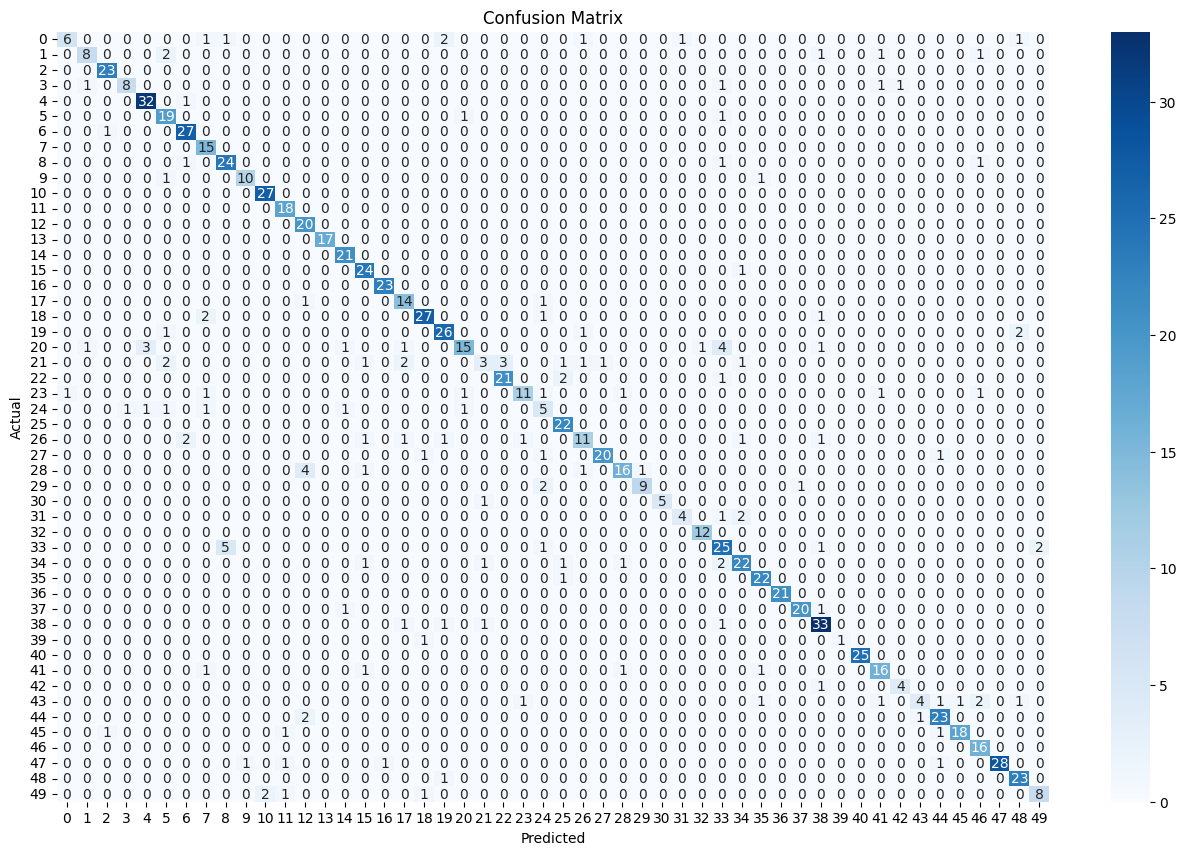

In [104]:
classes = np.unique(y_test)

import matplotlib.pyplot as plt
import seaborn as sns
# Plot confusion matrix using a heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [105]:

# print('precision: {}'.format(precision_score(y_test, y_pred, average='macro')))
# print('recall: {}'.format(recall_score(y_test, y_pred)))
# print('fscore: {}'.format(accuracy_score(y_test, y_pred)))
# print('support: {}'.format(f1_score(y_test, y_pred)))


precision: [0.85714286 0.8        0.92       0.88888889 0.88888889 0.73076923
 0.87096774 0.71428571 0.8        0.90909091 0.93103448 0.85714286
 0.74074074 1.         0.875      0.82758621 0.95833333 0.73684211
 0.9        0.83870968 0.83333333 0.5        0.875      0.84615385
 0.41666667 0.81481481 0.73333333 0.95238095 0.84210526 0.9
 1.         0.8        0.92307692 0.67567568 0.81481481 0.88
 1.         0.95238095 0.825      1.         1.         0.8
 0.8        0.8        0.85185185 0.94736842 0.76190476 1.
 0.85185185 0.8       ]
recall: [0.46153846 0.61538462 1.         0.66666667 0.96969697 0.9047619
 0.96428571 1.         0.88888889 0.83333333 1.         1.
 1.         1.         1.         0.96       1.         0.875
 0.87096774 0.86666667 0.55555556 0.2        0.875      0.61111111
 0.45454545 1.         0.57894737 0.86956522 0.69565217 0.75
 0.83333333 0.57142857 1.         0.73529412 0.78571429 0.95652174
 1.         0.90909091 0.89189189 0.5        1.         0.8
 0.8   

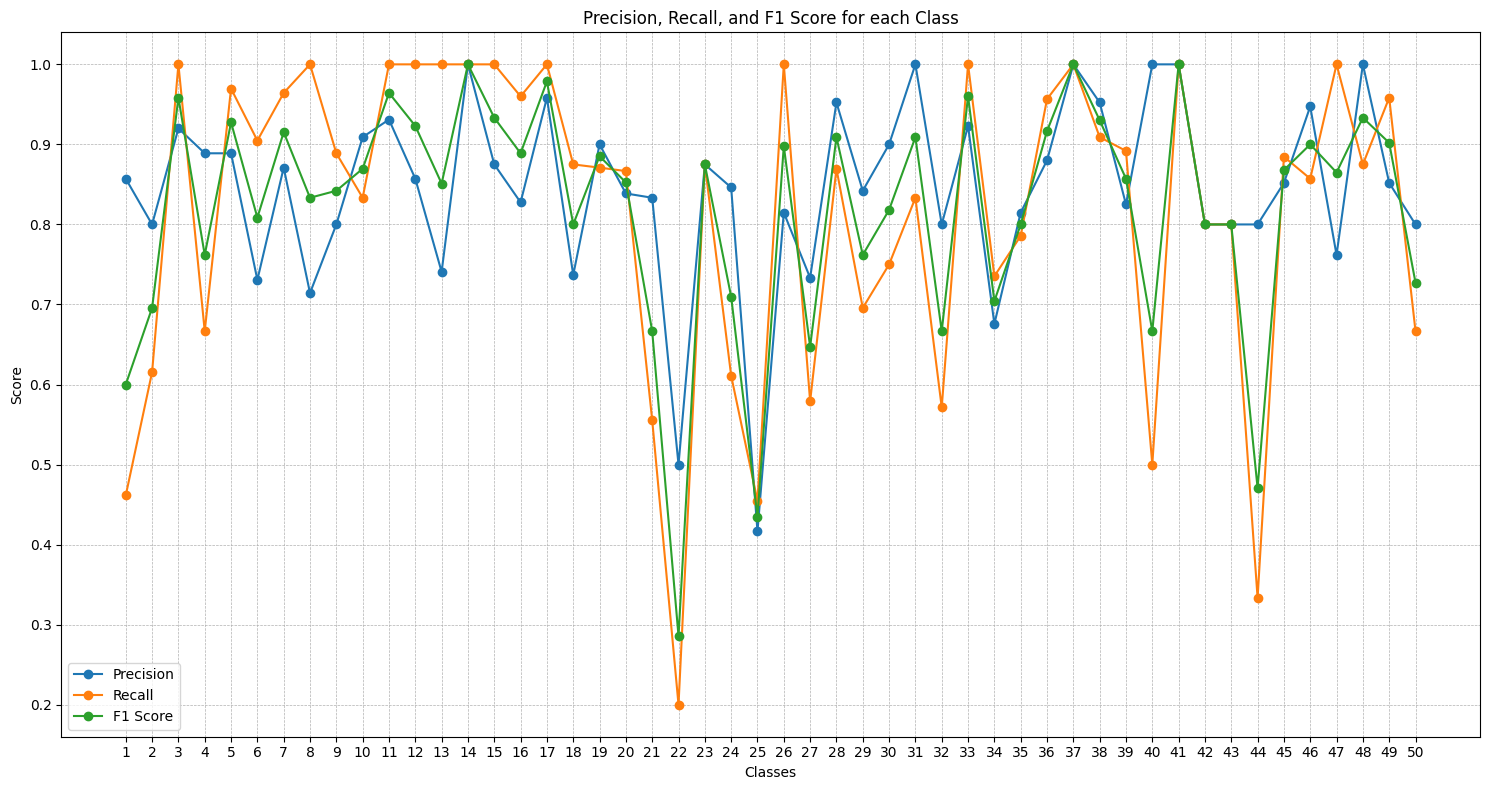

In [106]:
from sklearn.metrics import precision_recall_fscore_support as score
precision, recall, fscore, support = score(y_test, y_pred)


print('precision: {}'.format(precision))
print('recall: {}'.format(recall))
print('fscore: {}'.format(fscore))
print('support: {}'.format(support))

import matplotlib.pyplot as plt

# The data you provided
classes = list(range(1, 51))
# precision = [
#     0.9147286821705426, 0.984375, 0.9496644295302014, 0.9932203389830508, 1.0, 
#     # ... add all other precision values here
#     0.9501915708812261, 0.9921259842519685
# ]
# recall = [
#     0.9833333333333333, 0.9767441860465116, 0.9691780821917808, 0.9865319865319865, 1.0,
#     # ... add all other recall values here
#     0.9802371541501976, 0.9921259842519685
# ]
# f1 = [
#     0.9477911646586346, 0.980544747081712, 0.9593220338983051, 0.9898648648648648, 1.0,
#     # ... add all other F1 values here
#     0.9649805447470816, 0.9921259842519685
# ]

# Plotting
plt.figure(figsize=(15, 8))
plt.plot(classes, precision, marker='o', label='Precision')
plt.plot(classes, recall, marker='o', label='Recall')
plt.plot(classes, fscore, marker='o', label='F1 Score')
plt.xlabel('Classes')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score for each Class')
plt.xticks(classes)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


                  Feature  Importance
10                  Pitch    0.071654
16                 Timbre    0.067948
9         Chroma Features    0.059896
8       Spectral Contrast    0.058775
13          Spectral Flux    0.056032
6        Spectral Rolloff    0.055459
23  Energy Balance Metric    0.053480
5       Spectral Centroid    0.052721
1                     ZCR    0.047982
7       Spectral Flatness    0.043126
15       Wavelet Features    0.042866
18                 Jitter    0.035565
19                Shimmer    0.035128
2              Peak Value    0.033538
25                    SNR    0.031834
11                    HNR    0.026866
17               Loudness    0.023488
21            Mel-Spectra    0.023223
20      Bark Coefficients    0.023216
3                     STE    0.022562
0                     RMS    0.022253
22       Zwicker Loudness    0.021300
4           Signal Energy    0.021187
24                 LH1000    0.020852
14            Group Delay    0.020205
12         H

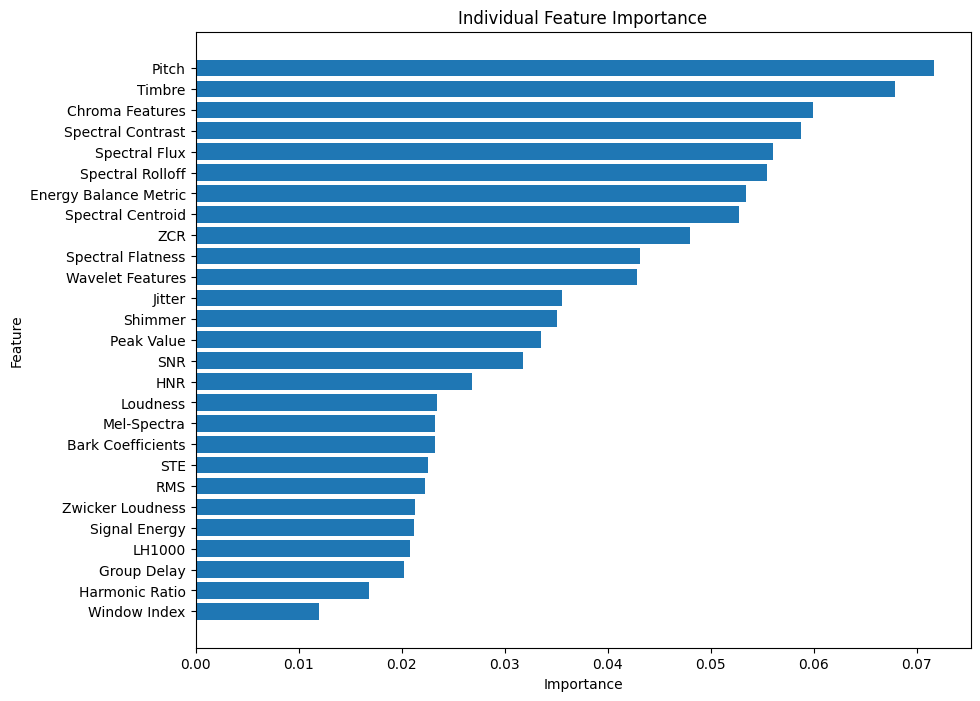

             Feature Group  Importance
1        Spectral Features    0.269977
0     Time Domain Analysis    0.147522
3  Time-Frequency Features    0.119102
2        Harmonic Features    0.115349
6         Derived Features    0.106166
4      Perceptual Features    0.091436
5  Psychoacoustic Features    0.067738


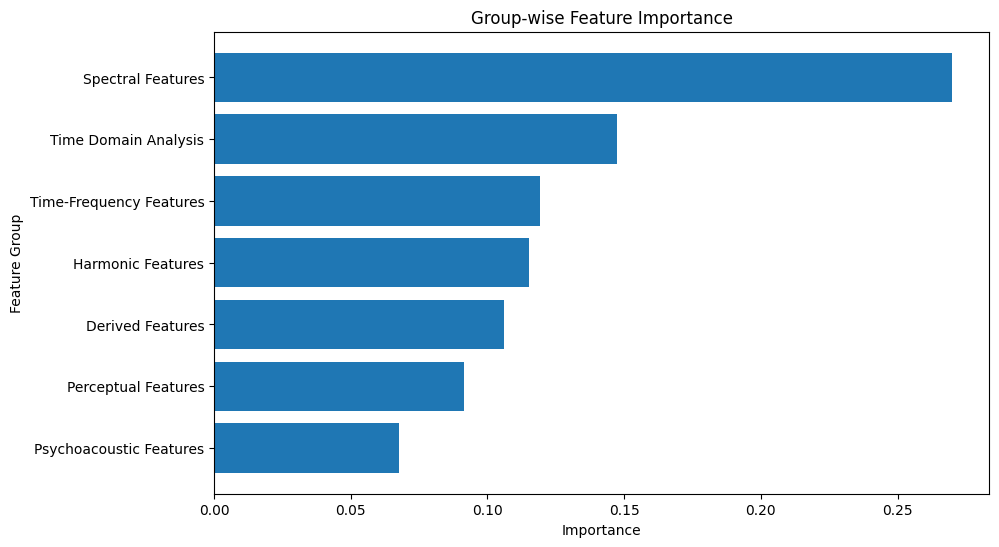

In [107]:
##Analyzing feature importances

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Example: If you have already trained a RandomForestClassifier called rf_model
# Assuming the features are in 'X_train' and target labels are in 'y_train'

# Fit the RF model (if not already trained)
# rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
# rf_model.fit(X_train, y_train)

# Get feature importances
feature_importances = clf.feature_importances_

# Create a DataFrame for individual feature importances
individual_importance_df = pd.DataFrame({
    'Feature':features_list3.iloc[:,:-1].columns,
    'Importance': feature_importances
})

# Sort by importance (descending)
individual_importance_df = individual_importance_df.sort_values(by='Importance', ascending=False)

# Display individual feature importances
print(individual_importance_df)

# Plot individual feature importances
plt.figure(figsize=(10, 8))
plt.barh(individual_importance_df['Feature'], individual_importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Individual Feature Importance')
plt.gca().invert_yaxis()
plt.show()

# Define feature groups (example groups based on your feature categorization)
feature_groups = {
    'Time Domain Analysis': ['RMS', 'ZCR', 'Peak Value', 'STE', 'Signal Energy'],
    'Spectral Features': ['Spectral Centroid', 'Spectral Rolloff', 'Spectral Flatness', 'Spectral Contrast', 'Chroma Features'],
    'Harmonic Features': ['Pitch', 'HNR',  'Harmonic Ratio'],
#     'Phonetic/Linguistic Features': ['MFCC', 'Formants', 'PLP-CC'],
    'Time-Frequency Features': ['Spectral Flux', 'Group Delay', 'Wavelet Features'],
    'Perceptual Features': ['Timbre', 'Loudness', 'Voice Quality (Jitter)', 'Voice Quality (Shimmer)'],
    'Psychoacoustic Features': ['Bark Coefficients', 'Mel-Spectra', 'Zwicker Loudness'],
    'Derived Features': ['Energy Balance Metric', 'LH1000', 'SNR']
}

# Calculate group-wise feature importance
group_importance = {}
for group, features in feature_groups.items():
    group_importance[group] = individual_importance_df[individual_importance_df['Feature'].isin(features)]['Importance'].sum()

# Convert to DataFrame for easier visualization
group_importance_df = pd.DataFrame({
    'Feature Group': list(group_importance.keys()),
    'Importance': list(group_importance.values())
}).sort_values(by='Importance', ascending=False)

# Display group-wise feature importances
print(group_importance_df)

# Plot group-wise feature importances
plt.figure(figsize=(10, 6))
plt.barh(group_importance_df['Feature Group'], group_importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature Group')
plt.title('Group-wise Feature Importance')
plt.gca().invert_yaxis()
plt.show()


In [202]:
# !pip install shap

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

# Assuming you have your dataset loaded in X and y
# Example split (replace with your actual data):
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Get permutation importance results
result = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42)

# Plot overall feature importance
importance_df = pd.DataFrame({
    'Feature': features_list3.iloc[:,:-1].columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Average Importance Score')
plt.title('Overall Feature Importance - Permutation')
plt.gca().invert_yaxis()
plt.show()

# If you want class-wise feature importance, evaluate predictions per class
classes = clf.classes_
for class_idx, class_name in enumerate(classes):
    # Mask the target to binary: 1 if it's the class, 0 otherwise
    y_binary = (y_test == class_name).astype(int)
    
    # Compute permutation importance for this specific class
    result = permutation_importance(clf, X_test, y_binary, n_repeats=10, random_state=42)
    print(result)
    class_importance_df = pd.DataFrame({
        'Feature': features_list3.iloc[:,:-1].columns,
        'Importance': result.importances_mean
    }).sort_values(by='Importance', ascending=False)

    # Plot the feature importance for this class
    plt.figure(figsize=(12, 8))
    plt.barh(class_importance_df['Feature'], class_importance_df['Importance'], color='lightgreen')
    plt.xlabel('Average Importance Score')
    plt.title(f'Feature Importance for Class: {class_name}')
    plt.gca().invert_yaxis()
    plt.show()


In [189]:
X_train.shape

(5548, 27)

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelBinarizer
from sklearn.datasets import make_classification

# Let's assume model, X, y are already defined
# model = RandomForestClassifier()
# model.fit(X, y)

# Binarize the output
label_binarizer = LabelBinarizer()
Y = label_binarizer.fit_transform(y)
n_classes = Y.shape[1]

# For each class, compute and plot feature importance
for i in range(n_classes):
    plt.figure(figsize=(10, 6))
    
    # Create a binary problem and train a model for this specific class
    binary_y = Y[:, i]
    binary_model = RandomForestClassifier(n_estimators=100)
    binary_model.fit(X_, binary_y)
    
    importances = binary_model.feature_importances_
    std = np.std([tree.feature_importances_ for tree in binary_model.estimators_], axis=0)
    indices = np.argsort(importances)[::-1]
    
    # Print the feature ranking
    class_label = label_binarizer.classes_[i]
    print(f"Feature ranking for class {class_label}:")
    
    for f in range(X_.shape[1]):
        print(f"{f + 1}. feature {indices[f]} ({importances[indices[f]]})")
    
    # Plot the feature importances of the forest
    plt.title(f"Feature importances for class {class_label}")
    plt.bar(range(X_.shape[1]), importances[indices], color="r", yerr=std[indices], align="center")
    plt.xticks(range(X_.shape[1]), indices)
    plt.xlim([-1, X_.shape[1]])
    plt.show()


NameError: name 'X_' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
# feature_names = ['energy', 'ZCR', 'RMS', 'peak value', 'spectral centroid', 'spectral BW', 'spectral flatness', 'spectral rolloff', 'spectral contrast', 'HNR', 'formant1', 'formant2', 'formant3', 'formant4', 'formant5'] + [f'MFCC{i}' for i in range(1, 21)] + ['fundamental frequency']
# feature_names = feature_names[:-16]

# feature_names = ['energy', 'ZCR', 'RMS', 'peak value', 'formant1', 'formant2', 'formant3', 'formant4', 'formant5', 'spectral centroid', 'spectral BW', 'spectral flatness', 'spectral rolloff'] + [f'spectral contrast{i}' for i in range(1, 8)] + ['HNR'] 


In [ ]:
len(feature_names)

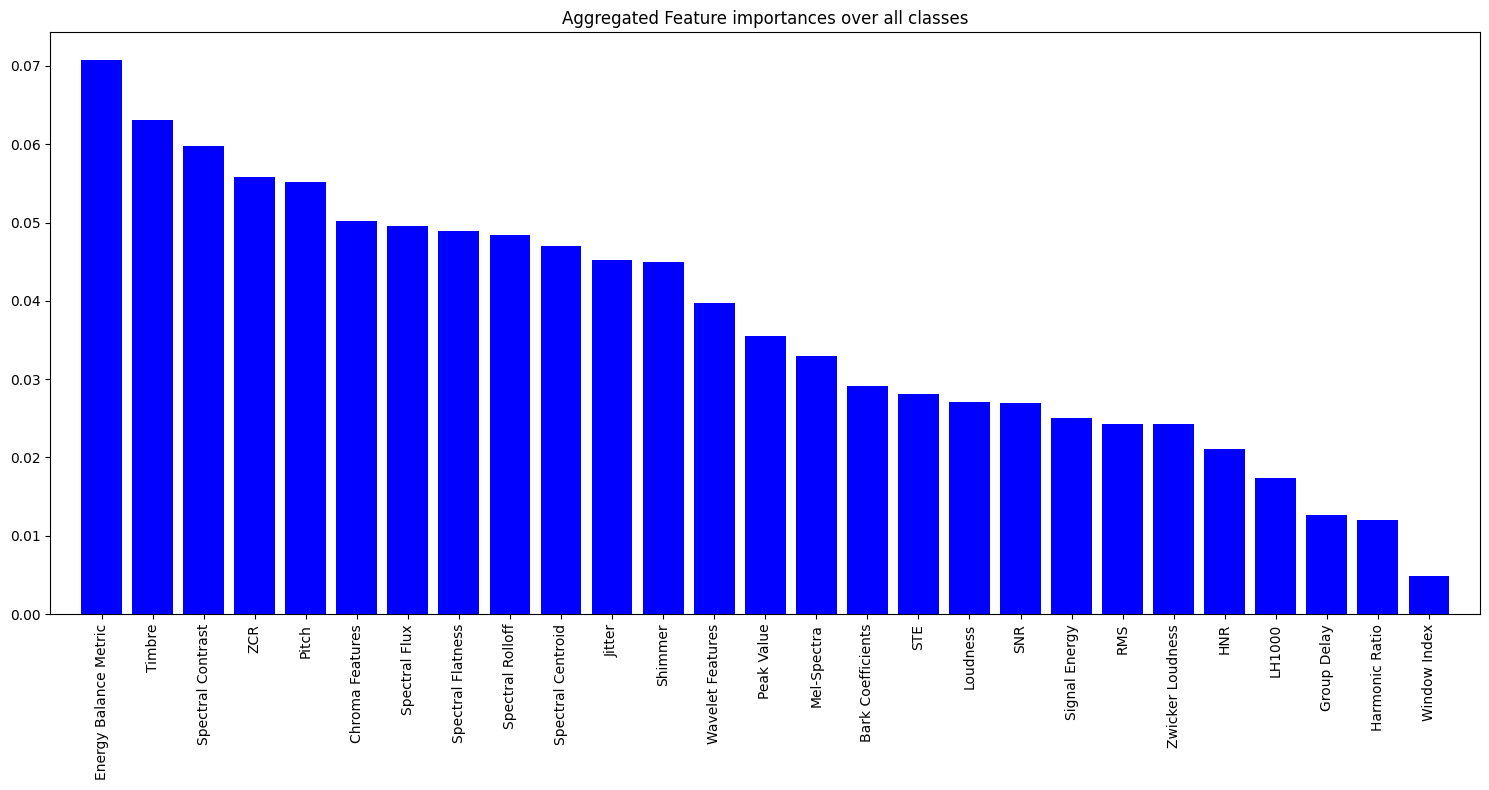

Ranking of features based on aggregated importance:
1. Energy Balance Metric (0.07074846612156614)
2. Timbre (0.06311571736013233)
3. Spectral Contrast (0.059745673832844966)
4. ZCR (0.05587046912341517)
5. Pitch (0.055124830455671806)
6. Chroma Features (0.05017080826506987)
7. Spectral Flux (0.04953752580978519)
8. Spectral Flatness (0.04890485392944869)
9. Spectral Rolloff (0.04840630703207073)
10. Spectral Centroid (0.04697329726467345)
11. Jitter (0.04521658026035875)
12. Shimmer (0.04498446411235076)
13. Wavelet Features (0.03974220290603531)
14. Peak Value (0.035551044903059804)
15. Mel-Spectra (0.032991581439611714)
16. Bark Coefficients (0.029160555207889172)
17. STE (0.028154616948325373)
18. Loudness (0.027127255955117068)
19. SNR (0.02689192749838891)
20. Signal Energy (0.024999659128832296)
21. RMS (0.02426822641588105)
22. Zwicker Loudness (0.024250528293516663)
23. HNR (0.02111296980126726)
24. LH1000 (0.017394599091983484)
25. Group Delay (0.012672749678521328)
26. Harm

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelBinarizer

# Updated Feature names
# feature_names = ['energy', 'ZCR', 'RMS', 'peak value', 'formant1', 'formant2', 'formant3', 'formant4', 'formant5', 'spectral centroid', 'spectral BW', 'spectral flatness', 'spectral rolloff'] + [f'spectral contrast{i}' for i in range(1, 8)] + ['HNR'] 
# Let's assume model, X, y are already defined
# model = RandomForestClassifier()
# model.fit(X, y)


X = X
y = y

# Binarize the output
label_binarizer = LabelBinarizer()
Y = label_binarizer.fit_transform(y)
n_classes = Y.shape[1]

feature_names= features_list3.iloc[:,:-1].columns

# Initialize a zero array to hold the aggregated feature importances
aggregate_importances = np.zeros(X.shape[1])

# For each class, compute feature importance
for i in range(n_classes):
    
    # Create a binary problem and train a model for this specific class
    binary_y = Y[:, i]
    binary_model = RandomForestClassifier(n_estimators=100)
    binary_model.fit(X, binary_y)
    
    # Aggregate feature importances
    aggregate_importances += binary_model.feature_importances_

# Normalize the aggregated feature importances
aggregate_importances /= n_classes

# Sort the features based on the aggregated importance
sorted_indices = np.argsort(aggregate_importances)[::-1]

# Print and Plot the aggregated feature importances
plt.figure(figsize=(15, 8))
plt.title("Aggregated Feature importances over all classes")
plt.bar(range(X.shape[1]), aggregate_importances[sorted_indices], color="b", align="center")
plt.xticks(range(X.shape[1]), [feature_names[i] for i in sorted_indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.tight_layout()  # To ensure the x-axis labels are visible
plt.show()

# Print the ranking of features
print("Ranking of features based on aggregated importance:")
for f in range(X.shape[1]):
    print(f"{f + 1}. {feature_names[sorted_indices[f]]} ({aggregate_importances[sorted_indices[f]]})")


In [76]:
len(feature_names), X.shape

(36, (70963, 16))

In [133]:
# # feature_names = ['energy', 'ZCR', 'RMS', 'peak value', 'formant1', 'formant2', 'formant3', 'formant4', 'formant5', 'spectral centroid', 'spectral BW', 'spectral flatness', 'spectral rolloff'] + [f'spectral contrast{i}' for i in range(1, 8)] + ['HNR'] 
# feature_names = ['energy', 'ZCR', 'RMS', 'peak value', 'spectral centroid', 'spectral BW', 'spectral flatness', 'spectral rolloff'] + [f'spectral contrast{i}' for i in range(1, 8)]+['HNR', 'formant1', 'formant2', 'formant3', 'formant4', 'formant5']  + [f'MFCC{i}' for i in range(1, 21)] + ['fundamental frequency']
# feature_names = feature_names[:-26]


# # Normalize the aggregated feature importances
# aggregate_importances /= n_classes

# # Sort the features based on the aggregated importance
# sorted_indices = np.argsort(aggregate_importances)[::-1]
# print(sorted_indices)

# # Print and Plot the aggregated feature importances
# plt.figure(figsize=(15, 8))
# # plt.title("Aggregated Feature importances over all classes")
# plt.bar(range(X.shape[1]), aggregate_importances[sorted_indices], align="center")
# plt.xticks(range(X.shape[1]), [feature_names[i] for i in sorted_indices], rotation=90, fontsize=14)
# plt.xlim([-1, X.shape[1]])
# plt.ylabel('Gini Importance', fontsize=14)
# plt.tight_layout()  # To ensure the x-axis labels are visible
# plt.show()


# # Print the ranking of features
# print("Ranking of features based on aggregated importance:")
# for f in range(X.shape[1]):
#     print(f"{f + 1}. {feature_names[sorted_indices[f]]} ({aggregate_importances[sorted_indices[f]]})")


[ 1 15 10 13 12  3  9  2  0 14  8 11  7  6  5  4]


IndexError: tuple index out of range

<Figure size 1500x800 with 0 Axes>

In [130]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelBinarizer

# Updated Feature names
# feature_names = ['energy', 'ZCR', 'RMS', 'peak value', 'spectral centroid', 'spectral BW', 'spectral flatness', 'spectral rolloff'] + [f'spectral contrast{i}' for i in range(1, 8)]+['HNR', 'formant1', 'formant2', 'formant3', 'formant4', 'formant5']  + [f'MFCC{i}' for i in range(1, 21)] + ['fundamental frequency']
# feature_names = feature_names[:-26]

# Let's assume model, X, y are already defined
# model = RandomForestClassifier()
# model.fit(X, y)
feature_names= features_list3.iloc[:,:-1].columns

# Binarize the output
label_binarizer = LabelBinarizer()
Y = label_binarizer.fit_transform(y)
n_classes = Y.shape[1]

# For each class, compute and plot feature importance
class_importances = {}
for i in range(n_classes):
    
    # Create a binary problem and train a model for this specific class
    binary_y = Y[:, i]
    binary_model = RandomForestClassifier(n_estimators=100)
    binary_model.fit(X, binary_y)
    
    importances = binary_model.feature_importances_
    std = np.std([tree.feature_importances_ for tree in binary_model.estimators_], axis=0)
    sorted_indices = np.argsort(importances)[::-1]
    
    # Print the feature ranking
    class_label = label_binarizer.classes_[i]
    print(f"Feature ranking for class {class_label}:")

    dict_ = {}
    for f in range(X.shape[1]):
        print(f"{f + 1}. {feature_names[sorted_indices[f]]} ({importances[sorted_indices[f]]})")
        dict_[feature_names[sorted_indices[f]]] = importances[sorted_indices[f]]

    class_importances[i] = dict_
    # # Plot the feature importances of the forest
    # plt.figure(figsize=(15, 8))
    # plt.title(f"Feature importances for class {class_label}")
    # plt.bar(range(X.shape[1]), importances[sorted_indices], color="r", yerr=std[sorted_indices], align="center")
    # plt.xticks(range(X.shape[1]), [feature_names[i] for i in sorted_indices], rotation=90)
    # plt.xlim([-1, X.shape[1]])
    # plt.tight_layout()  # To ensure the x-axis labels are visible
    # plt.show()


Feature ranking for class 0:
1. Energy Balance Metric (0.05684499667978183)
2. Timbre (0.05663820069820782)
3. LH1000 (0.05350370925008843)
4. Wavelet Features (0.04970216310501491)
5. Spectral Rolloff (0.04691147636268788)
6. Jitter (0.045942436240812935)
7. Shimmer (0.04563762411798442)
8. Bark Coefficients (0.04497123270892847)
9. Spectral Contrast (0.042890675022343894)
10. Spectral Centroid (0.042618243067137816)
11. Peak Value (0.04238087254435809)
12. Chroma Features (0.04189235096951591)
13. ZCR (0.035555140855687076)
14. Mel-Spectra (0.0354752701110304)
15. Signal Energy (0.03327325477850016)
16. Spectral Flatness (0.032999747821439065)
17. STE (0.032624418892376356)
18. SNR (0.030522655041680516)
19. Spectral Flux (0.02972584587252649)
20. Pitch (0.028404867993491484)
21. HNR (0.02817359998711376)
22. RMS (0.027752506306737545)
23. Zwicker Loudness (0.025802850456603677)
24. Group Delay (0.02466377755061286)
25. Harmonic Ratio (0.023663140395905752)
26. Loudness (0.0234337623

In [79]:
# feature_names = ['energy', 'ZCR', 'RMS', 'peak value', 'formant1', 'formant2', 'formant3', 'formant4', 'formant5', 'spectral centroid', 'spectral BW', 'spectral flatness', 'spectral rolloff'] + [f'spectral contrast{i}' for i in range(1, 8)] + ['HNR'] + [f'MFCC{i}' for i in range(1, 21)] + ['fundamental frequency']
len(feature_names)

42

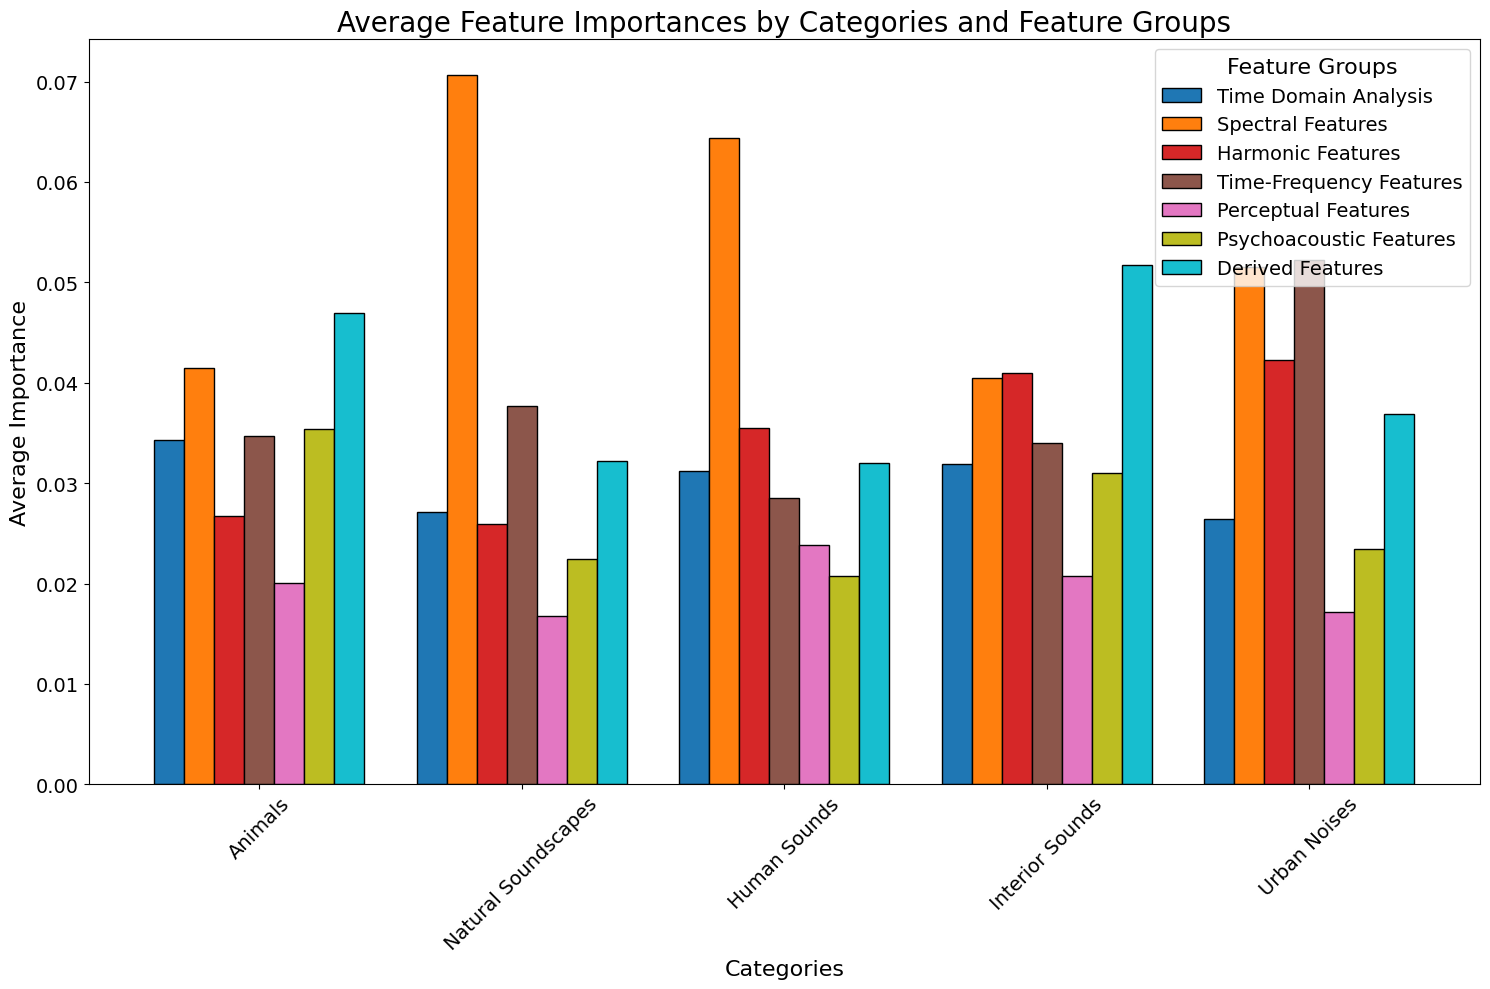

In [131]:
import matplotlib.pyplot as plt
import pandas as pd

# Feature groups
feature_groups = {
    'Time Domain Analysis': ['RMS', 'ZCR', 'Peak Value', 'STE', 'Signal Energy'],
    'Spectral Features': ['Spectral Centroid', 'Spectral Rolloff', 'Spectral Flatness', 'Spectral Contrast', 'Chroma Features'],
    'Harmonic Features': ['Pitch', 'HNR', 'Harmonic Ratio'],
    'Time-Frequency Features': ['Spectral Flux', 'Group Delay', 'Wavelet Features'],
    'Perceptual Features': ['Timbre', 'Loudness', 'Voice Quality (Jitter)', 'Voice Quality (Shimmer)'],
    'Psychoacoustic Features': ['Bark Coefficients', 'Mel-Spectra', 'Zwicker Loudness'],
    'Derived Features': ['Energy Balance Metric', 'LH1000', 'SNR']
}

# Example data structure for feature importance rankings (replace with actual values)
categories = ["Animals", "Natural Soundscapes", "Human Sounds", "Interior Sounds", "Urban Noises"]

# # Aggregate data for all classes (e.g., from your provided feature rankings)
# # Create a dictionary of feature importances for each class (fill with your actual values)
# class_importances = {
#     0: {"RMS": 0.026, "ZCR": 0.04, "Peak Value": 0.046, "Spectral Centroid": 0.04, "Timbre": 0.069, ...},  # Class 0 importances
#     1: {...},  # Class 1 importances
#     # Add all other classes
# }

# Aggregate feature importances for groups
group_importances = {category: {group: 0 for group in feature_groups.keys()} for category in categories}

for category_idx, category in enumerate(categories):
    for group, features in feature_groups.items():
        for feature in features:
            if feature in class_importances[category_idx]:  # Only aggregate existing features
                group_importances[category][group] += class_importances[category_idx][feature]
        # Average the importance for each group
        group_importances[category][group] /= len(features)

# Convert to DataFrame for easier manipulation
df_group_importances = pd.DataFrame(group_importances)

# Transpose to have categories on the x-axis
df_group_importances = df_group_importances.T

# Plot the results
df_group_importances.plot(
    kind='bar',
    figsize=(15, 10),
    width=0.8,
    edgecolor='black',
    colormap='tab10'
)

# Formatting
plt.title('Average Feature Importances by Categories and Feature Groups', fontsize=20)
plt.xlabel('Categories', fontsize=16)
plt.ylabel('Average Importance', fontsize=16)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14, loc="upper right", title="Feature Groups", title_fontsize=16)
plt.tight_layout()
plt.show()


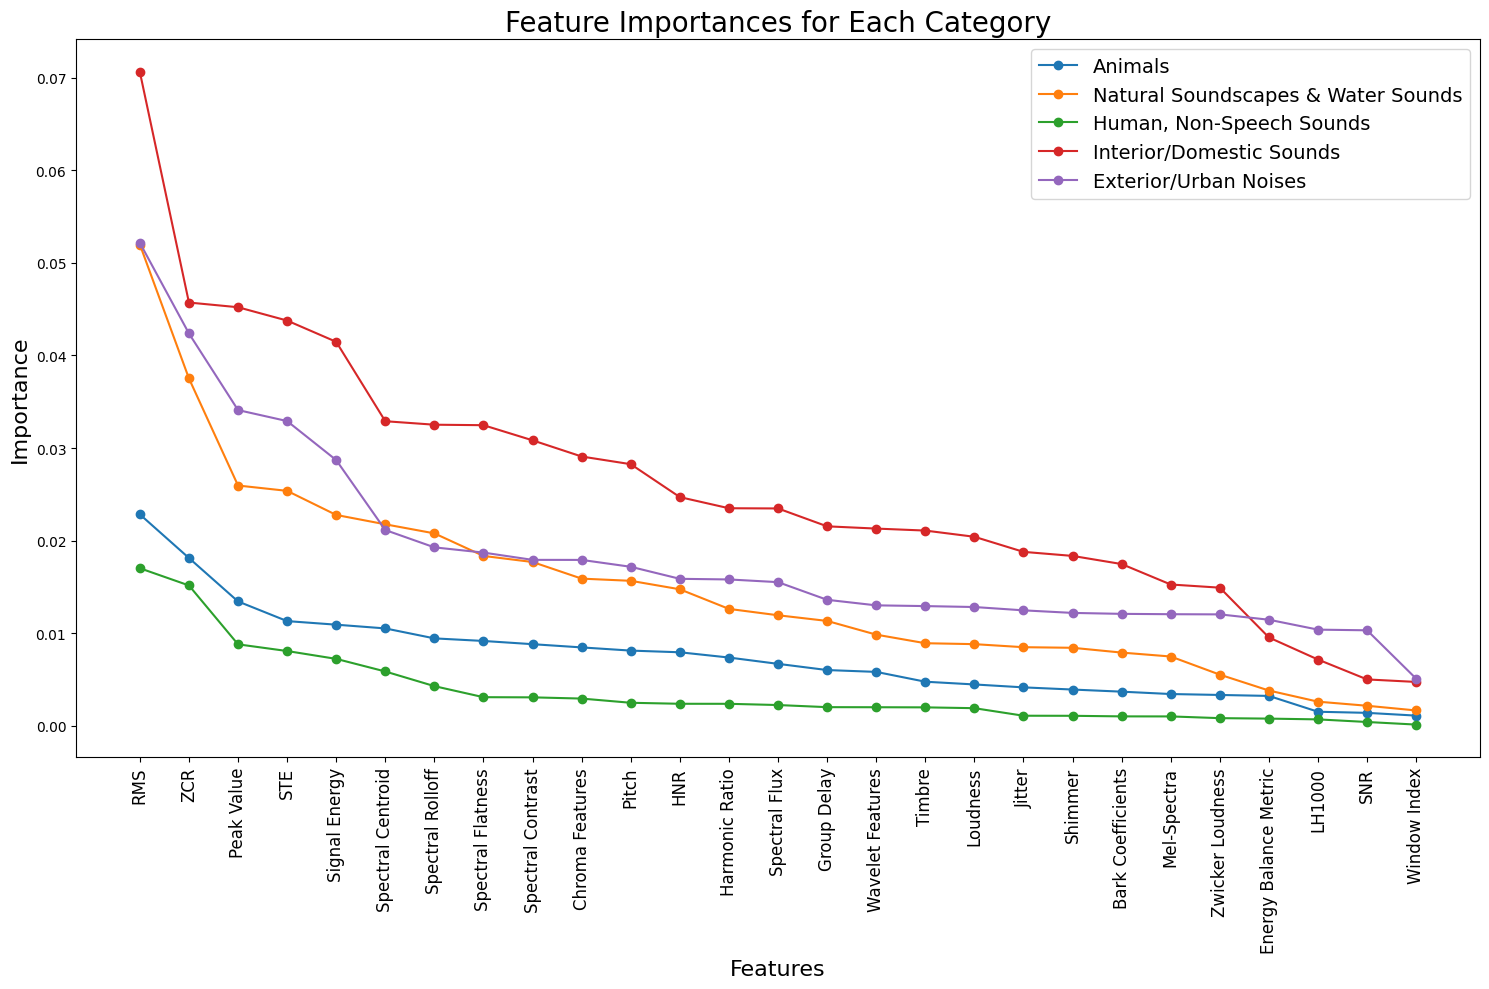

In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelBinarizer
import numpy as np
import matplotlib.pyplot as plt

# Assume X, y, and feature_names are already defined
# Define your category-to-classes mapping
categories = {
    "Animals": [0, 45, 41, 22, 25, 48, 43, 6, 35, 37],
    "Natural Soundscapes & Water Sounds": [28, 40, 26, 16, 14, 46, 15, 13, 39, 19],
    "Human, Non-Speech Sounds": [34, 42, 7, 33, 36, 20, 30, 31, 47, 27],
    "Interior/Domestic Sounds": [4, 11, 18, 5, 23, 44, 9, 17, 38, 3],
    "Exterior/Urban Noises": [1, 10, 12, 21, 32, 24, 29, 2, 8, 49],
}

# Binarize the output
label_binarizer = LabelBinarizer()
Y = label_binarizer.fit_transform(y)
n_classes = Y.shape[1]

# Store feature importances for each class
class_feature_importances = {}

for i in range(n_classes):
    binary_y = Y[:, i]
    binary_model = RandomForestClassifier(n_estimators=100, random_state=42)
    binary_model.fit(X, binary_y)
    
    class_feature_importances[i] = binary_model.feature_importances_

# Aggregate feature importances for each category
category_feature_importances = {category: np.zeros(X.shape[1]) for category in categories}

for category, class_indices in categories.items():
    for class_idx in class_indices:
        if class_idx in class_feature_importances:
            category_feature_importances[category] += class_feature_importances[class_idx]
    # Average by the number of classes in the category
    category_feature_importances[category] /= len(class_indices)

# Plot feature importances for each category
plt.figure(figsize=(15, 10))

for category, importances in category_feature_importances.items():
    sorted_indices = np.argsort(importances)[::-1]
    
    plt.plot(
        range(len(importances)),
        importances[sorted_indices],
        label=category,
        marker="o"
    )

# Formatting
plt.title("Feature Importances for Each Category", fontsize=20)
plt.xlabel("Features", fontsize=16)
plt.ylabel("Importance", fontsize=16)
plt.xticks(range(X.shape[1]), feature_names, rotation=90, fontsize=12)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()


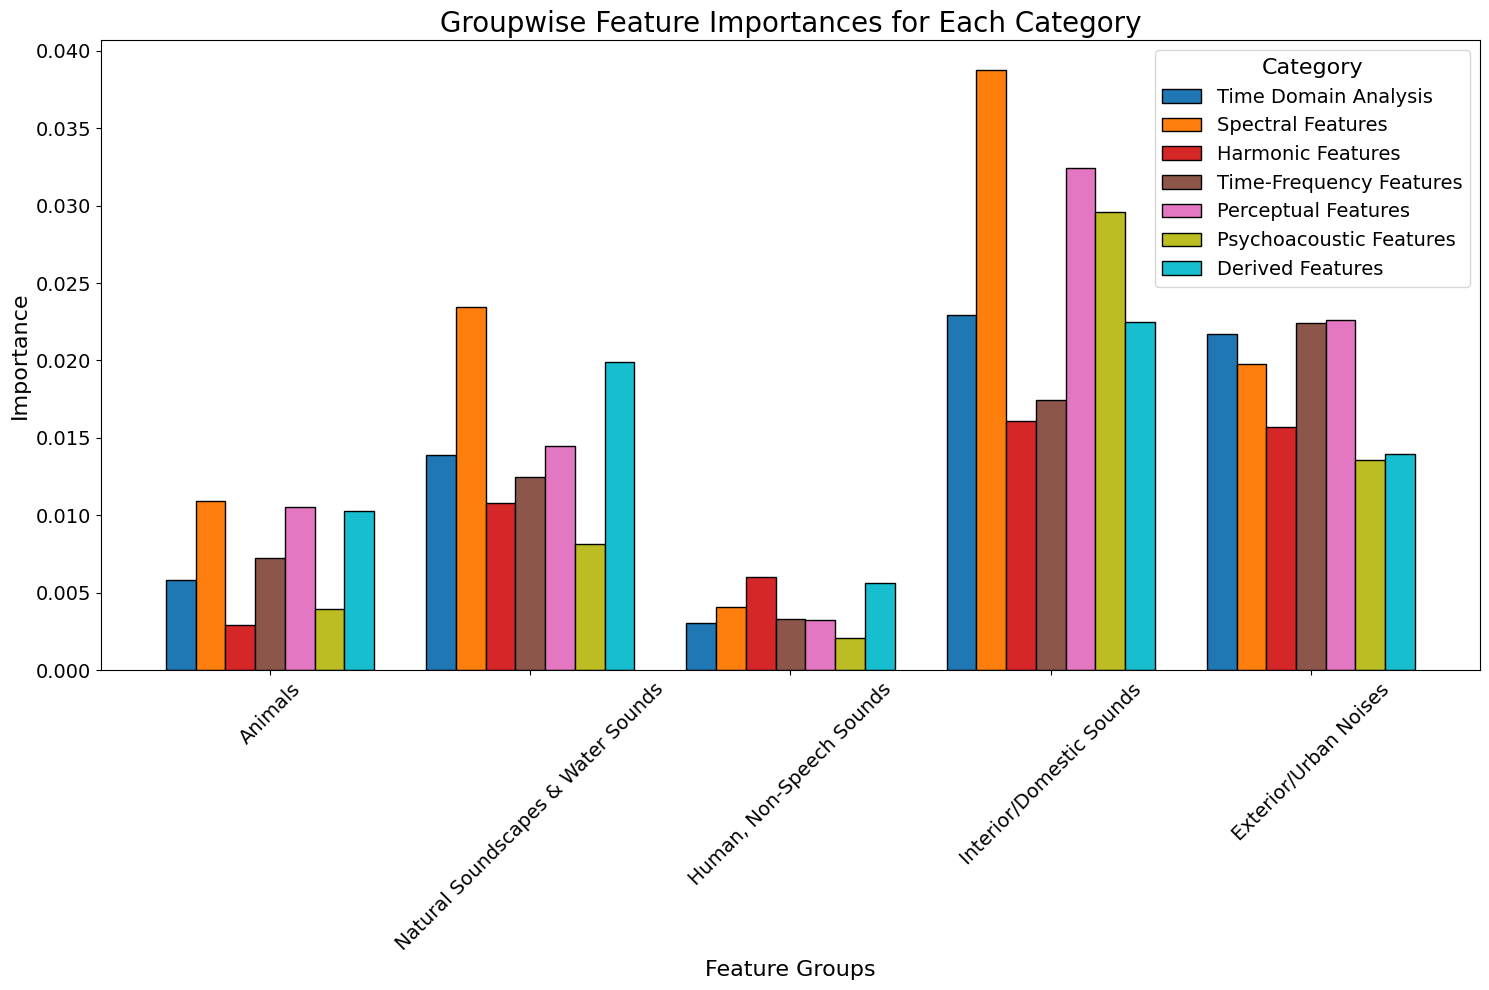

In [126]:
# Feature group mapping
feature_groups = {
    'Time Domain Analysis': ['RMS', 'ZCR', 'Peak Value', 'STE', 'Signal Energy'],
    'Spectral Features': ['Spectral Centroid', 'Spectral Rolloff', 'Spectral Flatness', 'Spectral Contrast', 'Chroma Features'],
    'Harmonic Features': ['Pitch', 'HNR', 'Harmonic Ratio'],
    'Time-Frequency Features': ['Spectral Flux', 'Group Delay', 'Wavelet Features'],
    'Perceptual Features': ['Timbre', 'Loudness', 'Voice Quality (Jitter)', 'Voice Quality (Shimmer)'],
    'Psychoacoustic Features': ['Bark Coefficients', 'Mel-Spectra', 'Zwicker Loudness'],
    'Derived Features': ['Energy Balance Metric', 'LH1000', 'SNR']
}

# Simulate feature names and their mapping to groups (replace with actual feature names)
all_features = sum(feature_groups.values(), [])  # Flatten the feature group list
feature_indices = {feature: i for i, feature in enumerate(all_features)}  # Assign indices

# Ensure your feature importances align with `all_features`
# feature_importances_matrix = np.random.rand(len(categories), len(all_features))  # Replace with actual importances
feature_importances_matrix = category_feature_importances
# Aggregate feature importances by group for each category
groupwise_importances = {category: {} for category in categories}

for category, importances in category_feature_importances.items():
    for group, features in feature_groups.items():
        group_indices = [feature_indices[feature] for feature in features if feature in feature_indices]
        group_importance = importances[group_indices].mean() if group_indices else 0
        groupwise_importances[category][group] = group_importance

# Convert to DataFrame for easier plotting
df_groupwise_importances = pd.DataFrame(groupwise_importances)

# Plot groupwise feature importances
df_groupwise_importances.T.plot(
    kind="bar",
    figsize=(15, 10),
    width=0.8,
    edgecolor="black",
    colormap="tab10",
)

# Formatting
plt.title("Groupwise Feature Importances for Each Category", fontsize=20)
plt.ylabel("Importance", fontsize=16)
plt.xlabel("Feature Groups", fontsize=16)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14, loc="upper right", title="Category", title_fontsize=16)
plt.tight_layout()
plt.show()


In [117]:
# # Rewriting the corrected code for plotting groupwise feature importances

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # Define feature groups
# feature_groups = {
#     'Time Domain Analysis': ['RMS', 'ZCR', 'Peak Value', 'STE', 'Signal Energy'],
#     'Spectral Features': ['Spectral Centroid', 'Spectral Rolloff', 'Spectral Flatness', 'Spectral Contrast', 'Chroma Features'],
#     'Harmonic Features': ['Pitch', 'HNR', 'Harmonic Ratio'],
#     'Time-Frequency Features': ['Spectral Flux', 'Group Delay', 'Wavelet Features'],
#     'Perceptual Features': ['Timbre', 'Loudness', 'Voice Quality (Jitter)', 'Voice Quality (Shimmer)'],
#     'Psychoacoustic Features': ['Bark Coefficients', 'Mel-Spectra', 'Zwicker Loudness'],
#     'Derived Features': ['Energy Balance Metric', 'LH1000', 'SNR']
# }

# # Simulate feature names and feature importances
# all_features = sum(feature_groups.values(), [])  # Flatten feature group list
# feature_indices = {feature: i for i, feature in enumerate(all_features)}  # Map feature to index
# n_categories = 5
# n_features = len(all_features)

# # Simulate feature importances for categories (replace with actual values)
# category_names = ["Animals", "Natural Soundscapes", "Human Sounds", "Interior Sounds", "Urban Noises"]
# feature_importances_matrix = category_feature_importances

# # Aggregate feature importances by group for each category
# groupwise_importances = {category: {} for category in category_names}

# for cat_idx, category in enumerate(category_names):
#     for group, features in feature_groups.items():
#         group_indices = [feature_indices[feature] for feature in features if feature in feature_indices]
#         group_importance = feature_importances_matrix[cat_idx, group_indices].sum() if group_indices else 0
#         groupwise_importances[category][group] = group_importance

# # Convert to DataFrame for easier plotting
# df_groupwise_importances = pd.DataFrame(groupwise_importances)

# # Transpose the DataFrame to have categories on x-axis
# df_groupwise_importances = df_groupwise_importances.T

# # Plot with categories on x-axis and feature groups as legends
# df_groupwise_importances.plot(
#     kind="bar",
#     figsize=(15, 10),
#     width=0.8,
#     edgecolor="black",
#     colormap="tab10"
# )

# # Formatting
# plt.title("Feature Importances by Categories and Feature Groups", fontsize=20)
# plt.ylabel("Importance", fontsize=16)
# plt.xlabel("Categories", fontsize=16)
# plt.xticks(rotation=45, fontsize=14)
# plt.yticks(fontsize=14)
# plt.legend(
#     fontsize=14,
#     loc="upper right",
#     title="Feature Groups",
#     title_fontsize=16
# )
# plt.tight_layout()
# plt.show()



TypeError: unhashable type: 'list'

In [124]:
feature_importances_matrix

{'Animals': array([0.00669136, 0.01051791, 0.00476306, 0.00333263, 0.00368821,
        0.0109215 , 0.00846682, 0.01812302, 0.00794106, 0.00916323,
        0.00582354, 0.00151984, 0.00139999, 0.00944242, 0.00343289,
        0.00881518, 0.0228324 , 0.00391743, 0.0073735 , 0.00812273,
        0.00446729, 0.00415254, 0.00322846, 0.01343182, 0.01130767,
        0.00602187, 0.00110162]),
 'Natural Soundscapes & Water Sounds': array([0.01565865, 0.02175983, 0.01193808, 0.00881934, 0.01132738,
        0.01834453, 0.02277026, 0.01262531, 0.0259478 , 0.03751497,
        0.02078121, 0.00891926, 0.00260747, 0.01768878, 0.0038101 ,
        0.01589373, 0.02537255, 0.00790808, 0.01474331, 0.00984627,
        0.0074845 , 0.0084902 , 0.00842617, 0.05197256, 0.00216589,
        0.0055254 , 0.00165837]),
 'Human, Non-Speech Sounds': array([0.00237637, 0.00586715, 0.00294317, 0.0020064 , 0.00199308,
        0.00108973, 0.00108172, 0.00224425, 0.00722889, 0.00879926,
        0.01701615, 0.00041308, 0.00069

In [83]:
X.shape

(70963, 16)

In [94]:
feature_names = ['energy', 'ZCR', 'RMS', 'peak value', 'formant1', 'formant2', 'formant3', 'formant4', 'formant5', 'spectral centroid', 'spectral BW', 'spectral flatness', 'spectral rolloff'] + [f'spectral contrast{i}' for i in range(1, 8)] + ['HNR'] + [f'MFCC{i}' for i in range(1, 21)] + ['fundamental frequency']

feature_values = [5.36318398e+01, 3.98404208e-01, 2.11871937e-02, 2.91809082e-01, 8.72630920e+02, 9.06393677e+02, 9.32497314e+02, 9.43086182e+02, 1.06946826e+03, 1.06029837e+04, 4.81161295e+03, 3.12744707e-01, 1.57412609e+04, 8.36915017e+00, 7.39511880e+00, 9.28489404e+00, 1.20502612e+01, 1.60105151e+01, 1.84078397e+01, 2.36899452e+01, 1.04202425e+00, -6.68151489e+02, -2.88678417e+01, -1.21740026e+01, 1.53598509e+01, -6.51576805e+00, 1.13960352e+01, -1.06159420e+01, -2.49587834e-01, 1.00122416e+00, 3.78168797e+00, 1.35483757e-01, -2.86324000e+00, -1.93524742e+00, 1.71072376e+00, 3.56045127e+00, -2.79734135e+00, -6.33295953e-01, 3.65585357e-01, -3.98711562e-01, 6.74959004e-01, 1.84366432e+03]

feature_dict = {name: value for name, value in zip(feature_names, feature_values)}

print(feature_dict)


{'energy': 53.6318398, 'ZCR': 0.398404208, 'RMS': 0.0211871937, 'peak value': 0.291809082, 'formant1': 872.63092, 'formant2': 906.393677, 'formant3': 932.497314, 'formant4': 943.086182, 'formant5': 1069.46826, 'spectral centroid': 10602.9837, 'spectral BW': 4811.61295, 'spectral flatness': 0.312744707, 'spectral rolloff': 15741.2609, 'spectral contrast1': 8.36915017, 'spectral contrast2': 7.3951188, 'spectral contrast3': 9.28489404, 'spectral contrast4': 12.0502612, 'spectral contrast5': 16.0105151, 'spectral contrast6': 18.4078397, 'spectral contrast7': 23.6899452, 'HNR': 1.04202425, 'MFCC1': -668.151489, 'MFCC2': -28.8678417, 'MFCC3': -12.1740026, 'MFCC4': 15.3598509, 'MFCC5': -6.51576805, 'MFCC6': 11.3960352, 'MFCC7': -10.615942, 'MFCC8': -0.249587834, 'MFCC9': 1.00122416, 'MFCC10': 3.78168797, 'MFCC11': 0.135483757, 'MFCC12': -2.86324, 'MFCC13': -1.93524742, 'MFCC14': 1.71072376, 'MFCC15': 3.56045127, 'MFCC16': -2.79734135, 'MFCC17': -0.633295953, 'MFCC18': 0.365585357, 'MFCC19': -

In [95]:
import tensorflow

SyntaxError: invalid syntax (pywrap_tensorflow_internal.py, line 114)

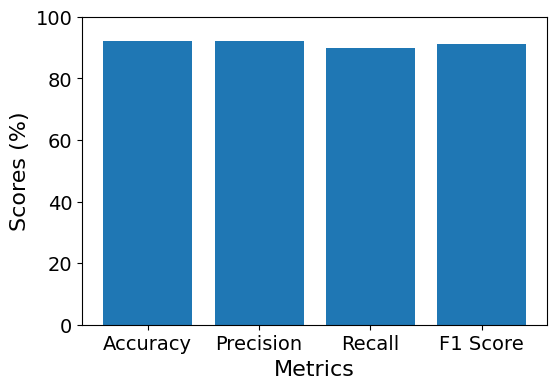

In [137]:
import matplotlib.pyplot as plt

# Data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
# values = [88.76, 89, 86, 87]
values = [92.23, 92, 90, 91]

# Creating the bar plot
plt.figure(figsize=(6, 4))
plt.bar(metrics, values)

plt.xlabel('Metrics', fontsize=16)
plt.ylabel('Scores (%)', fontsize=16)
# plt.title('Model Performance Metrics')
plt.ylim(0, 100)  # Setting the limit for y-axis to make the graph easier to read
plt.grid(axis='y', linestyle='')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# Display the plot
plt.show()

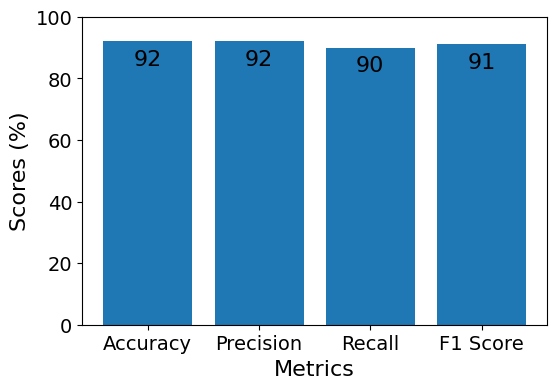

In [11]:
import matplotlib.pyplot as plt

# Data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [92, 92, 90, 91]

# Creating the bar plot
plt.figure(figsize=(6, 4))
bar_positions = range(len(metrics))
bars = plt.bar(bar_positions, values)

# Annotate the bar values
for i, v in enumerate(values):
    plt.text(i, v - 9, str(v), color='black', fontsize=16, ha='center', va='bottom')

plt.xlabel('Metrics', fontsize=16)
plt.ylabel('Scores (%)', fontsize=16)
plt.ylim(0, 100)  # Setting the limit for y-axis to make the graph easier to read
plt.grid(axis='y', linestyle='')
plt.xticks(bar_positions, metrics, fontsize=14)
plt.yticks(fontsize=14)

# Display the plot
plt.show()

In [2]:
X_train

NameError: name 'X_train' is not defined